# 01 · Three-Sigma Is Broken

The *three standard deviations* rule is the first outlier filter most analysts reach for. It fails in exactly the two situations outlier detection exists to handle: **extreme values** and **skew**.

This notebook demonstrates both failures on data where we *know* the ground truth, and shows the robust **IQR** rule getting right what three-sigma gets wrong on the very same data.

Every figure is written to `outputs/figures/` and every number to `outputs/data/`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "pyproject.toml").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.artifacts import save_figure, save_json

plt.rcParams["figure.dpi"] = 110
SEED = 7

from src.evaluation.masking import masking_demo, swamping_demo, make_masking_example
from src.datasets.synthetic import make_skewed_1d
from src.detectors.statistical import IQRDetector
from src.visualisation import masking_figure

## 1 · Masking — the rule hides the outlier that broke it

Three-sigma uses the **mean** and **standard deviation**, both of which are inflated by extreme values. Add enough extreme points and the standard deviation balloons until the `mean ± 3·std` band stretches *past the outliers themselves*. The rule then flags none of them — it is defeated by the very points it exists to catch.

three-sigma band : [-38.88, 51.56]
the 8 outliers all sit at value 40 -> INSIDE the band
three-sigma recall on the outliers : 0%
IQR recall on the same outliers    : 100%


PosixPath('/workspaces/outlier_arena/outputs/data/01_masking.json')

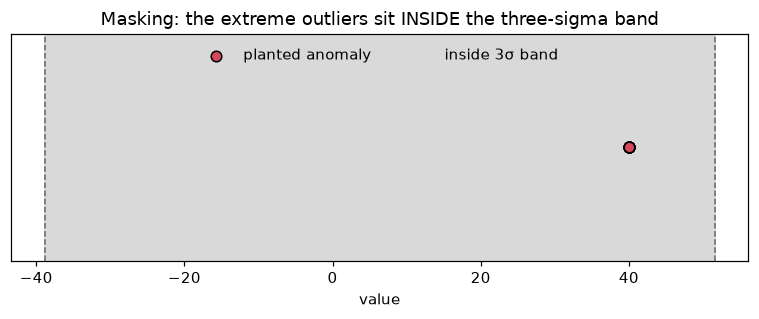

In [2]:
demo = masking_demo(n_clean=40, n_outliers=8, outlier_value=40.0, seed=SEED)
x, y = make_masking_example(n_clean=40, n_outliers=8, outlier_value=40.0, seed=SEED)

print(f"three-sigma band : [{demo.three_sigma_lower:.2f}, {demo.three_sigma_upper:.2f}]")
print(f"the 8 outliers all sit at value 40 -> INSIDE the band")
print(f"three-sigma recall on the outliers : {demo.three_sigma_recall:.0%}")
print(f"IQR recall on the same outliers    : {demo.robust_recall:.0%}")

fig = masking_figure(
    x, y, demo.three_sigma_lower, demo.three_sigma_upper,
    title="Masking: the extreme outliers sit INSIDE the three-sigma band",
)
save_figure(fig, "01_masking_band")

save_json({
    "inputs": {"n_clean": 40, "n_outliers": 8, "outlier_value": 40.0, "seed": SEED},
    "three_sigma_band": [demo.three_sigma_lower, demo.three_sigma_upper],
    "three_sigma_recall": demo.three_sigma_recall,
    "iqr_recall": demo.robust_recall,
    "three_sigma_false_positives": demo.three_sigma_false_positives,
}, "01_masking")

### Masking is a mathematical certainty, not bad luck

If `m` of `n` points are identical extreme outliers, each outlier's z-score is

$$z = \sqrt{\dfrac{n-m}{m}}$$

— **independent of how extreme the value is**. Once `m` is large enough that this is below 3, no outlier can ever clear the threshold, however far out you push it.

With n=48, once m >= 5 the outliers can never be flagged.


PosixPath('/workspaces/outlier_arena/outputs/data/01_masking_certainty.json')

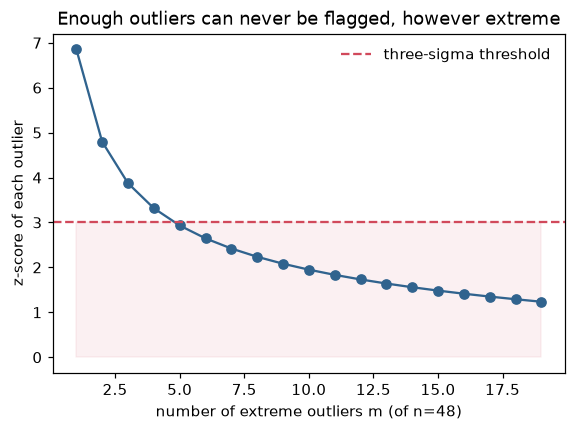

In [3]:
n = 48
ms = np.arange(1, 20)
z_scores = np.sqrt((n - ms) / ms)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ms, z_scores, "o-", color="#30638e")
ax.axhline(3.0, color="#d1495b", ls="--", label="three-sigma threshold")
ax.fill_between(ms, 0, 3.0, color="#d1495b", alpha=0.08)
ax.set(xlabel="number of extreme outliers m (of n=48)",
       ylabel="z-score of each outlier",
       title="Enough outliers can never be flagged, however extreme")
ax.legend(frameon=False)
save_figure(fig, "01_masking_certainty")

masked_from = int(ms[z_scores < 3.0].min())
print(f"With n={n}, once m >= {masked_from} the outliers can never be flagged.")
save_json({
    "n": n, "m": ms.tolist(), "z_score": z_scores.tolist(), "threshold": 3.0,
    "masked_once_m_at_least": masked_from,
    "formula": "z = sqrt((n - m) / m), independent of the outlier value",
}, "01_masking_certainty")

## 2 · Skew — swamping the long tail, missing the short side

Three-sigma also assumes a symmetric bell. On right-skewed data (most business data) the long right tail inflates the std, so the symmetric band:

- **swamps** the tail — flags legitimate far-right points as outliers, and
- **misses the short side** — its lower bound is pushed so far left that a genuine small-value anomaly sits comfortably inside it.

The **IQR** rule, built on quartiles, has asymmetric fences that hug the data and catch the short-side anomaly.

three-sigma recall on the real anomaly : 0% (and it swamped 11 legitimate tail points)
IQR recall on the real anomaly         : 100%


PosixPath('/workspaces/outlier_arena/outputs/data/01_swamping.json')

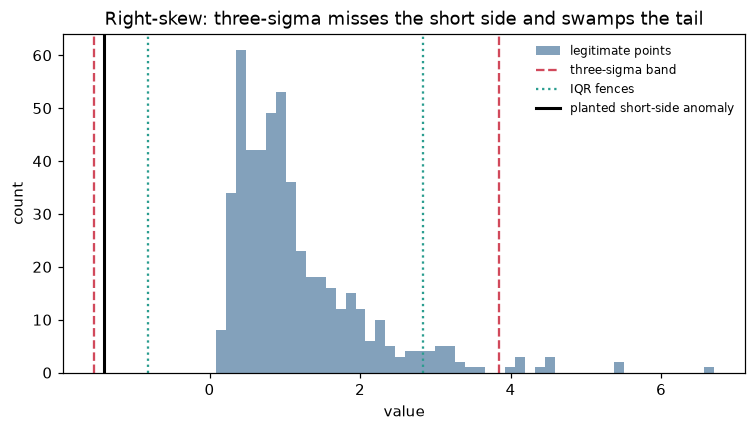

In [4]:
sd = swamping_demo(seed=SEED)
xs, ys = make_skewed_1d(seed=SEED)

q1, q3 = np.percentile(xs, [25, 75])
iqr_val = q3 - q1
iqr_lower, iqr_upper = q1 - 1.5 * iqr_val, q3 + 1.5 * iqr_val
anomaly_value = float(xs[ys][0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(xs[~ys], bins=50, color="#30638e", alpha=0.6, label="legitimate points")
ax.axvline(sd.three_sigma_lower, color="#d1495b", ls="--", label="three-sigma band")
ax.axvline(sd.three_sigma_upper, color="#d1495b", ls="--")
ax.axvline(iqr_lower, color="#2a9d8f", ls=":", label="IQR fences")
ax.axvline(iqr_upper, color="#2a9d8f", ls=":")
ax.axvline(anomaly_value, color="k", lw=2, label="planted short-side anomaly")
ax.set(xlabel="value", ylabel="count",
       title="Right-skew: three-sigma misses the short side and swamps the tail")
ax.legend(frameon=False, fontsize=8)
save_figure(fig, "01_skew_swamping")

print(f"three-sigma recall on the real anomaly : {sd.three_sigma_recall:.0%} "
      f"(and it swamped {sd.three_sigma_false_positives} legitimate tail points)")
print(f"IQR recall on the real anomaly         : {sd.robust_recall:.0%}")

save_json({
    "inputs": {"seed": SEED,
               "distribution": "lognormal(mean=0, sigma=0.75) + one short-side anomaly"},
    "short_side_value": anomaly_value,
    "three_sigma_band": [sd.three_sigma_lower, sd.three_sigma_upper],
    "iqr_fences": [float(iqr_lower), float(iqr_upper)],
    "three_sigma_recall": sd.three_sigma_recall,
    "three_sigma_tail_false_positives": sd.three_sigma_false_positives,
    "iqr_recall": sd.robust_recall,
}, "01_swamping")

## Takeaway

The field's default outlier rule is unreliable in precisely the conditions outlier detection is for. Use the **IQR** rule (or the modified z-score) instead of plain three-sigma — it is a one-line change that is immune to masking and far better under skew.

In [5]:
summary = {
    "notebook": "01_three_sigma_is_broken",
    "claims": {
        "masking": ("Three-sigma's own inflated std moves the band past the extreme "
                    "outliers, so it flags none of them; IQR flags all."),
        "masking_is_exact": ("Each outlier's z-score is sqrt((n-m)/m), independent of "
                             "how extreme the value is."),
        "skew": ("On right-skewed data three-sigma misses the short-side anomaly and "
                 "swamps legitimate long-tail points; IQR catches the anomaly."),
    },
    "headline_numbers": {
        "masking_three_sigma_recall": demo.three_sigma_recall,
        "masking_iqr_recall": demo.robust_recall,
        "skew_three_sigma_recall": sd.three_sigma_recall,
        "skew_three_sigma_false_positives": sd.three_sigma_false_positives,
        "skew_iqr_recall": sd.robust_recall,
    },
}
save_json(summary, "01_summary")
summary

{'notebook': '01_three_sigma_is_broken',
 'claims': {'masking': "Three-sigma's own inflated std moves the band past the extreme outliers, so it flags none of them; IQR flags all.",
  'masking_is_exact': "Each outlier's z-score is sqrt((n-m)/m), independent of how extreme the value is.",
  'skew': 'On right-skewed data three-sigma misses the short-side anomaly and swamps legitimate long-tail points; IQR catches the anomaly.'},
 'headline_numbers': {'masking_three_sigma_recall': 0.0,
  'masking_iqr_recall': 1.0,
  'skew_three_sigma_recall': 0.0,
  'skew_three_sigma_false_positives': 11,
  'skew_iqr_recall': 1.0}}